#  Phase 5: Credit Scorecard System

**Project:** Credit Default Risk Modeling
**Phase:** 5 — FICO-Style Credit Scorecard

---

##  What is a Credit Scorecard?

A scorecard converts a logistic regression model into a **human-readable points system** — exactly like FICO (300–850).

Instead of saying *"probability of default = 0.34"*, a bank says:
> *"Your credit score is 620 — Medium Risk"*

This is what **JPMorgan, Amex, Capital One** actually use internally.

---

##  The Math

$$\text{Factor} = \frac{PDO}{\ln(2)}, \quad \text{Offset} = \text{Base Score} - \text{Factor} \times \ln(\text{Base Odds})$$

$$\text{Points}_{ij} = -\left(\beta_i \times WoE_{ij} + \frac{\beta_0}{k}\right) \times \text{Factor}$$

---

##  Score Bands

| Score | Risk Band | Decision |
|---|---|---|
| 750+ | Very Low Risk | Auto Approve  |
| 650–749 | Low Risk | Approve  |
| 550–649 | Medium Risk | Manual Review  |
| 450–549 | High Risk | Decline  |
| < 450 | Very High Risk | Auto Decline |

## 1 Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

# Scorecard parameters
BASE_SCORE = 600
BASE_ODDS  = 1
PDO        = 20

print(f'Base Score={BASE_SCORE} | Base Odds={BASE_ODDS} | PDO={PDO}')
print('Libraries loaded successfully.')

Base Score=600 | Base Odds=1 | PDO=20
Libraries loaded successfully.


## 2 Load & Prepare Data

In [4]:
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')

column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

numeric_selected     = ['duration_months', 'credit_amount', 'age', 'installment_rate']
categorical_selected = [
    'checking_account', 'credit_history', 'purpose', 'savings_account',
    'employment_years', 'personal_status', 'other_debtors', 'property',
    'other_installments', 'housing', 'foreign_worker'
]
selected_features = numeric_selected + categorical_selected

print(f'Shape: {data.shape} | Default Rate: {data["target"].mean()*100:.1f}%')
print('Data ready for modeling.')

Shape: (1000, 21) | Default Rate: 30.0%
Data ready for modeling.


## 3 WoE Encoding (Full Dataset)

In [5]:
def compute_woe_iv(df, feature, target, bins=10, is_numeric=True):
    df = df[[feature, target]].copy()
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events
    df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop') if is_numeric else df[feature]
    grouped = df.groupby('bin', observed=True)[target].agg(
        Events='sum', Total='count').reset_index()
    grouped['NonEvents']      = grouped['Total'] - grouped['Events']
    eps = 0.5
    grouped['pct_Events']    = (grouped['Events']    + eps) / (total_events     + eps)
    grouped['pct_NonEvents'] = (grouped['NonEvents'] + eps) / (total_non_events + eps)
    grouped['WoE']           = np.log(grouped['pct_Events'] / grouped['pct_NonEvents'])
    grouped['IV']            = (grouped['pct_Events'] - grouped['pct_NonEvents']) * grouped['WoE']
    grouped['Default_Rate']  = grouped['Events'] / grouped['Total']
    return grouped[['bin','Total','Events','NonEvents','Default_Rate','WoE','IV']].round(4), round(grouped['IV'].sum(), 4)


woe_tables = {}
woe_maps   = {}
df_encoded = data.copy()

for feat in selected_features:
    is_num = feat in numeric_selected
    try:
        woe_df, iv = compute_woe_iv(data, feat, 'target', bins=10, is_numeric=is_num)
        woe_tables[feat] = woe_df
        if is_num:
            df_encoded[f'{feat}_bin'] = pd.qcut(data[feat], q=10, duplicates='drop')
            woe_map = woe_df.set_index('bin')['WoE'].to_dict()
            df_encoded[f'{feat}_woe'] = df_encoded[f'{feat}_bin'].map(woe_map)
            df_encoded.drop(columns=[f'{feat}_bin'], inplace=True)
        else:
            woe_map = woe_df.set_index('bin')['WoE'].to_dict()
            df_encoded[f'{feat}_woe'] = data[feat].map(woe_map)
        woe_maps[feat] = woe_map
    except Exception as e:
        print(f'  Skipped {feat}: {e}')

woe_cols = [f'{f}_woe' for f in selected_features if f'{f}_woe' in df_encoded.columns]
print(f'WoE encoding complete   →  {len(woe_cols)} features')

WoE encoding complete   →  15 features


## 4 Train Logistic Regression

In [6]:
X = df_encoded[woe_cols].dropna()
y = df_encoded.loc[X.index, 'target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

lr = sm.Logit(y_train, X_train_sm).fit(method='newton', maxiter=100, disp=False)

y_prob_test = lr.predict(X_test_sm)
auc = roc_auc_score(y_test, y_prob_test)
print(f'Model fitted   |  Test AUC: {auc:.4f}')

Model fitted   |  Test AUC: 0.7765


## 5 Compute Scaling Constants

In [7]:
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS + 1e-9)

print(f'Factor = {factor:.4f}')
print(f'Offset = {offset:.4f}')
print(f'Score = Offset + Factor x (-(intercept/k + beta_i x WoE_ij)) summed over all features')

Factor = 28.8539
Offset = 600.0000
Score = Offset + Factor x (-(intercept/k + beta_i x WoE_ij)) summed over all features


## 6 Build Scorecard — Points per Bin

In [8]:
intercept          = lr.params['const']
n_features         = len(woe_cols)
intercept_per_feat = intercept / n_features

scorecard_rows = []

for feat in selected_features:
    woe_col = f'{feat}_woe'
    if woe_col not in woe_cols:
        continue
    beta = lr.params.get(woe_col, None)
    if beta is None:
        continue
    for _, row in woe_tables[feat].iterrows():
        woe_val = float(row['WoE'])
        points  = -(float(beta) * woe_val + intercept_per_feat) * factor
        scorecard_rows.append({
            'Feature'     : feat,
            'Bin'         : str(row['bin']),
            'Count'       : int(row['Total']),
            'Default_Rate': round(float(row['Default_Rate']), 4),
            'WoE'         : round(woe_val, 4),
            'Beta'        : round(float(beta), 4),
            'Points'      : round(points, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)

print('=== CREDIT SCORECARD ===')
print(f'Features: {scorecard_df["Feature"].nunique()} | Bins: {len(scorecard_df)}')
print()
print(scorecard_df.to_string(index=False))

=== CREDIT SCORECARD ===
Features: 15 | Bins: 79

           Feature               Bin  Count  Default_Rate     WoE   Beta  Points
   duration_months      (3.999, 9.0]    143        0.1678 -0.7383 0.7954    18.7
   duration_months       (9.0, 12.0]    216        0.2407 -0.2958 0.7954     8.6
   duration_months      (12.0, 15.0]     72        0.1806 -0.6369 0.7954    16.4
   duration_months      (15.0, 18.0]    115        0.3739  0.3355 0.7954    -5.9
   duration_months      (18.0, 24.0]    224        0.2946 -0.0222 0.7954     2.3
   duration_months      (24.0, 30.0]     57        0.3333  0.1661 0.7954    -2.0
   duration_months      (30.0, 36.0]     86        0.4419  0.6154 0.7954   -12.4
   duration_months      (36.0, 72.0]     87        0.5172  0.9146 0.7954   -19.2
     credit_amount  (249.999, 934.7]    100        0.3100  0.0550 0.7782     0.5
     credit_amount   (934.7, 1262.0]    101        0.2970 -0.0056 0.7782     1.9
     credit_amount  (1262.0, 1479.4]     99        0.2626 -

## 7 Score All Applicants

In [9]:
def get_score_band(score):
    if score >= 750:   return 'Very Low Risk',  'Auto Approve'
    elif score >= 650: return 'Low Risk',        'Approve'
    elif score >= 550: return 'Medium Risk',     'Manual Review'
    elif score >= 450: return 'High Risk',       'Decline'
    else:              return 'Very High Risk',  'Auto Decline'


X_full_sm   = sm.add_constant(df_encoded[woe_cols].dropna())
y_full      = df_encoded.loc[X_full_sm.index, 'target']
log_odds    = X_full_sm @ lr.params
prob_full   = 1 / (1 + np.exp(-log_odds))
scores_full = offset - factor * log_odds

df_scored = data.loc[X_full_sm.index].copy()
df_scored['credit_score'] = scores_full.round().astype(int)
df_scored['default_prob'] = prob_full.round(4)
df_scored['score_band']   = df_scored['credit_score'].apply(lambda s: get_score_band(s)[0])
df_scored['decision']     = df_scored['credit_score'].apply(lambda s: get_score_band(s)[1])

print(f'All applicants scored  | Sample Scores:')
print(f'Score Range : {df_scored["credit_score"].min()} – {df_scored["credit_score"].max()}')
print(f'Mean Score  : {df_scored["credit_score"].mean():.1f}')
print()
print('Score Band Distribution:')
print(df_scored['score_band'].value_counts().to_string())

All applicants scored  | Sample Scores:
Score Range : 510 – 772
Mean Score  : 636.1

Score Band Distribution:
score_band
Medium Risk      575
Low Risk         392
High Risk         30
Very Low Risk      3


## 8 Score Distribution Plots

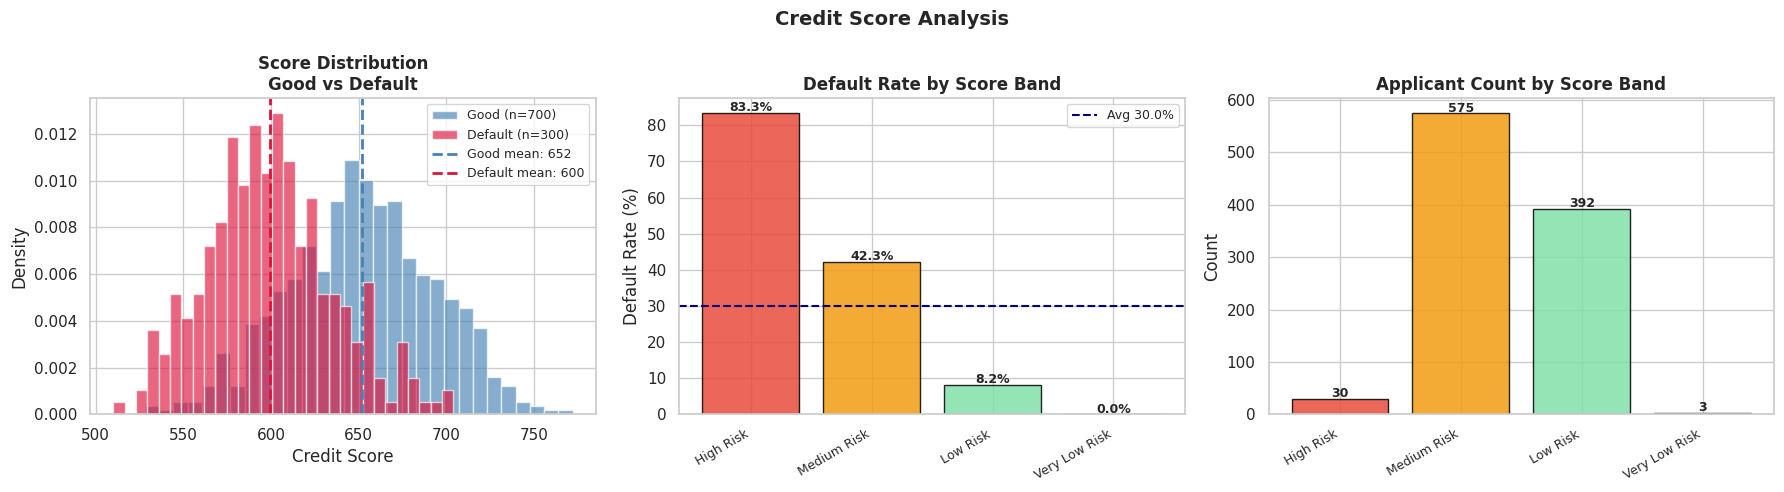

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

good_scores    = df_scored[df_scored['target']==0]['credit_score']
default_scores = df_scored[df_scored['target']==1]['credit_score']

# Distribution
axes[0].hist(good_scores,    bins=30, alpha=0.65, color='steelblue', density=True,
             label=f'Good (n={len(good_scores)})')
axes[0].hist(default_scores, bins=30, alpha=0.65, color='crimson',   density=True,
             label=f'Default (n={len(default_scores)})')
axes[0].axvline(good_scores.mean(),    color='steelblue', linestyle='--', linewidth=2,
                label=f'Good mean: {good_scores.mean():.0f}')
axes[0].axvline(default_scores.mean(), color='crimson',   linestyle='--', linewidth=2,
                label=f'Default mean: {default_scores.mean():.0f}')
axes[0].set_title('Score Distribution\nGood vs Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Default rate by band
band_order = ['Very High Risk','High Risk','Medium Risk','Low Risk','Very Low Risk']
band_stats = df_scored.groupby('score_band').agg(
    Count=('target','count'), Default_Rate=('target','mean')
).reindex([b for b in band_order if b in df_scored['score_band'].unique()])

bar_colors_all = ['#922b21','#e74c3c','#f39c12','#82e0aa','#2ecc71']
n_bands = len(band_stats)
band_colors = bar_colors_all[-n_bands:]

bars = axes[1].bar(range(n_bands), band_stats['Default_Rate']*100,
                   color=band_colors, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(n_bands))
axes[1].set_xticklabels(band_stats.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, band_stats['Default_Rate']*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(df_scored['target'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg {df_scored["target"].mean()*100:.1f}%')
axes[1].set_title('Default Rate by Score Band', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend(fontsize=9)

# Count by band
axes[2].bar(range(n_bands), band_stats['Count'],
            color=band_colors, edgecolor='black', alpha=0.85)
axes[2].set_xticks(range(n_bands))
axes[2].set_xticklabels(band_stats.index, rotation=30, ha='right', fontsize=9)
for i, cnt in enumerate(band_stats['Count']):
    axes[2].text(i, cnt+3, str(int(cnt)), ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Applicant Count by Score Band', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Credit Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9 Points per Bin — Top 6 Features

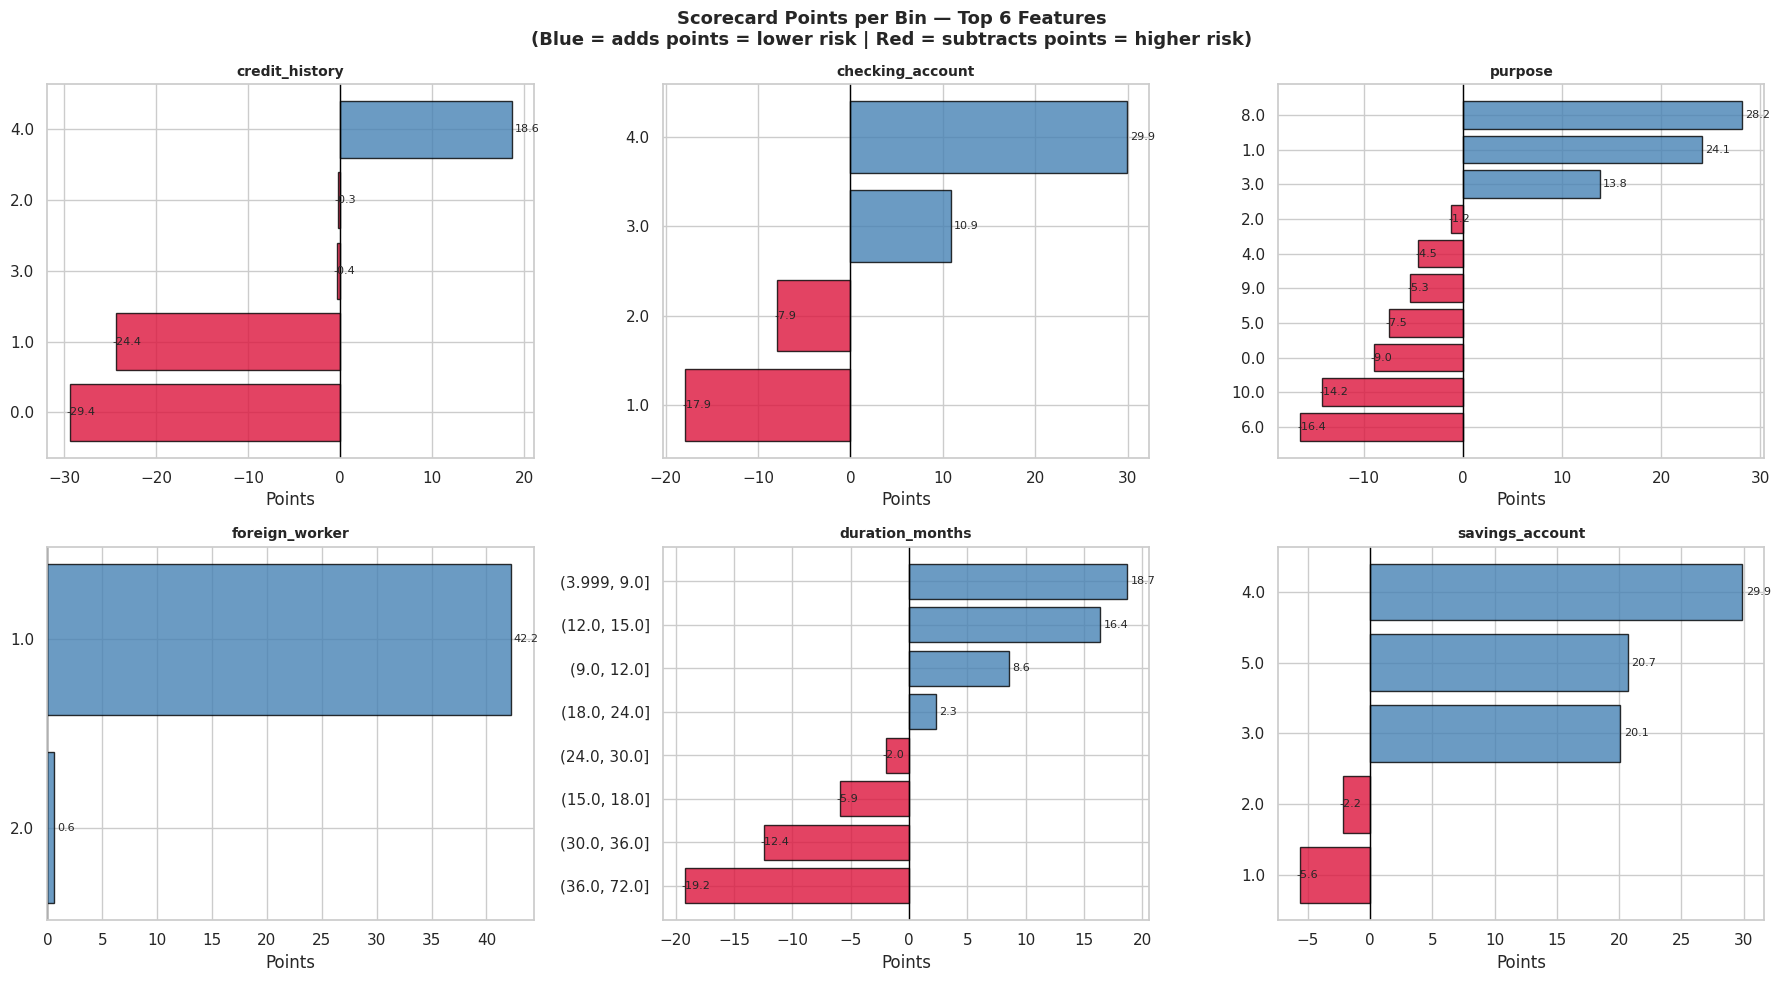

In [11]:
top_features = scorecard_df.groupby('Feature')['Points'].apply(
    lambda x: x.max() - x.min()
).nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_df = scorecard_df[scorecard_df['Feature']==feat].sort_values('Points')
    colors  = ['crimson' if p < 0 else 'steelblue' for p in feat_df['Points']]
    labels  = [str(b)[:25] for b in feat_df['Bin']]

    axes[i].barh(labels, feat_df['Points'], color=colors, edgecolor='black', alpha=0.8)
    axes[i].axvline(0, color='black', linewidth=1)
    for bar, val in zip(axes[i].patches, feat_df['Points']):
        xpos = bar.get_width() + (0.3 if val >= 0 else -0.3)
        axes[i].text(xpos, bar.get_y()+bar.get_height()/2,
                     f'{val:.1f}', va='center', fontsize=8)
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Points')

plt.suptitle('Scorecard Points per Bin — Top 6 Features\n'
             '(Blue = adds points = lower risk | Red = subtracts points = higher risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 Live Applicant Scoring — 3 Example Cases

In [13]:
def score_applicant(app_dict):
    """Score a single applicant using the trained scorecard."""
    row = {}
    for feat in selected_features:
        woe_col = f'{feat}_woe'
        if woe_col not in woe_cols:
            continue
        raw_val = app_dict.get(feat)
        woe_map = woe_maps.get(feat, {})
        woe_val = None
        if feat in numeric_selected:
            for interval, w in woe_map.items():
                try:
                    if raw_val in interval:
                        woe_val = w
                        break
                except:
                    pass
            if woe_val is None:
                lefts = [iv.left for iv in woe_map.keys()]
                woe_val = list(woe_map.values())[0] if raw_val <= min(lefts) else list(woe_map.values())[-1]
        else:
            woe_val = woe_map.get(raw_val, 0.0)
        row[woe_col] = woe_val if woe_val is not None else 0.0

    woe_series = pd.Series(row)
    woe_series_const = pd.concat([pd.Series({'const': 1.0}), woe_series])
    log_odds  = lr.params.reindex(woe_series_const.index).fillna(0).dot(woe_series_const)
    prob      = float(1 / (1 + np.exp(-log_odds)))
    score     = int(round(offset - factor * log_odds))

    # Point breakdown
    breakdown = []
    for feat in selected_features:
        woe_col = f'{feat}_woe'
        if woe_col not in woe_cols:
            continue
        beta   = float(lr.params.get(woe_col, 0))
        woe_v  = row.get(woe_col, 0.0)
        pts    = -(beta * woe_v + intercept_per_feat) * factor
        breakdown.append({'Feature': feat, 'Raw': app_dict.get(feat), 'WoE': round(woe_v,4), 'Points': round(pts,1)})

    return score, round(prob, 4), pd.DataFrame(breakdown)


applicants = {
    'Low Risk Applicant': {
        'duration_months':12, 'credit_amount':1500, 'age':45, 'installment_rate':1,
        'checking_account':4, 'credit_history':4, 'purpose':0, 'savings_account':5,
        'employment_years':5, 'personal_status':3, 'other_debtors':1, 'property':1,
        'other_installments':3, 'housing':2, 'foreign_worker':2
    },
    'Medium Risk Applicant': {
        'duration_months':24, 'credit_amount':4000, 'age':30, 'installment_rate':3,
        'checking_account':2, 'credit_history':2, 'purpose':1, 'savings_account':2,
        'employment_years':3, 'personal_status':2, 'other_debtors':1, 'property':2,
        'other_installments':3, 'housing':1, 'foreign_worker':2
    },
    'High Risk Applicant': {
        'duration_months':48, 'credit_amount':9000, 'age':22, 'installment_rate':4,
        'checking_account':1, 'credit_history':0, 'purpose':2, 'savings_account':1,
        'employment_years':1, 'personal_status':1, 'other_debtors':2, 'property':3,
        'other_installments':1, 'housing':3, 'foreign_worker':1
    }
}

print('=' * 65)
for name, app in applicants.items():
    score, prob, breakdown = score_applicant(app)
    band, decision = get_score_band(score)
    print(f'\n {name}')
    print(f'   Credit Score       : {score}')
    print(f'   Default Probability: {prob*100:.1f}%')
    print(f'   Risk Band          : {band}')
    print(f'   Decision           : {decision}')
    print(f'   Top 3 Risk Factors :')
    for _, r in breakdown.nsmallest(3,'Points').iterrows():
        print(f'   - {r["Feature"]:<25} Raw={r["Raw"]}  Points={r["Points"]}')
    print('-' * 65)


 Low Risk Applicant
   Credit Score       : 730
   Default Probability: 1.1%
   Risk Band          : Low Risk
   Decision           : Approve
   Top 3 Risk Factors :
   - purpose                   Raw=0  Points=-9.0
   - foreign_worker            Raw=2  Points=0.6
   - other_debtors             Raw=1  Points=1.8
-----------------------------------------------------------------

 Medium Risk Applicant
   Credit Score       : 621
   Default Probability: 32.6%
   Risk Band          : Medium Risk
   Decision           : Manual Review
   Top 3 Risk Factors :
   - checking_account          Raw=2  Points=-7.9
   - personal_status           Raw=2  Points=-6.5
   - housing                   Raw=1  Points=-2.7
-----------------------------------------------------------------

 High Risk Applicant
   Credit Score       : 506
   Default Probability: 96.3%
   Risk Band          : High Risk
   Decision           : Decline
   Top 3 Risk Factors :
   - credit_history            Raw=0  Points=-29.4
  

## 11 Scorecard Validation

In [14]:
test_scored = df_scored.loc[y_test.index].copy()

fpr, tpr, _ = roc_curve(y_test, -test_scored['credit_score'])
auc_sc = roc_auc_score(y_test, -test_scored['credit_score'])
ks_sc  = float(np.max(tpr - fpr))

print('=== Scorecard Performance (Test Set) ===')
print(f'  ROC-AUC      : {auc_sc:.4f}')
print(f'  KS Statistic : {ks_sc:.4f}')
print(f'  Gini Coeff   : {2*auc_sc-1:.4f}')

print('\n=== Score Band Performance ===')
band_perf = test_scored.groupby('score_band').agg(
    Count=('target','count'),
    Defaults=('target','sum'),
    Default_Rate=('target','mean'),
    Avg_Score=('credit_score','mean')
).round(3)
print(band_perf.to_string())

=== Scorecard Performance (Test Set) ===
  ROC-AUC      : 0.7761
  KS Statistic : 0.4310
  Gini Coeff   : 0.5523

=== Score Band Performance ===
               Count  Defaults  Default_Rate  Avg_Score
score_band                                             
High Risk          9         7         0.778    539.556
Low Risk          73         8         0.110    679.603
Medium Risk      117        45         0.385    612.068
Very Low Risk      1         0         0.000    772.000


## 12 Save Outputs

In [15]:
scorecard_df.to_csv('credit_scorecard.csv', index=False)
df_scored[['credit_score','default_prob','score_band','decision','target']].to_csv(
    'applicants_scored.csv', index=False)

print('credit_scorecard.csv saved ')
print('applicants_scored.csv saved ')
print(f'Score Range: {df_scored["credit_score"].min()} – {df_scored["credit_score"].max()}')

credit_scorecard.csv saved 
applicants_scored.csv saved 
Score Range: 510 – 772


##  Key Interview Talking Points

**On what a scorecard is:**
*"A credit scorecard translates logistic regression coefficients into a human-readable points system. Each feature bin is assigned a fixed point value — the total is the applicant's credit score. This is how FICO, Experian, and internal bank scorecards actually work."*

**On PDO:**
*"PDO — Points to Double the Odds — is the scaling parameter. With PDO=20, every 20-point score increase doubles the odds of being a good borrower. The base score of 600 anchors at 1:1 good-to-bad odds."*

**On regulatory compliance:**
*"For any decline decision, I can tell the applicant exactly which factors cost them points — checking account status cost 22 points, credit history cost 18 points. This explainability is required under GDPR Article 22 and the US Fair Credit Reporting Act."*

**On Basel II connection:**
*"This scorecard outputs a Probability of Default (PD) per applicant. Combined with LGD and EAD, it feeds directly into Expected Loss = PD × LGD × EAD — the Basel II IRB framework — which is exactly what Phase 6 builds."*

---
**Next Phase:** Portfolio Risk Simulation — Expected Loss, Monte Carlo, Value at Risk 